# London PM2.5 annual average concentrations (LAEI 2022)

* Author: Andrew Sivanesan
* Date: Feb 2026
* 
## FixMe (20260223)

* Customise legend and tooltips in choropleth map

## Import modules

In [1]:
import pandas as pd
import geopandas as gpd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fname_grid = "LAEI2019_grid.shp"

In [3]:
grid = gpd.read_file(fname_grid)

## Read in PM 2.5 concentrations data

* High data resolution: 20 metre x 20 metre squares
* Circa 6 million rows of data

In [4]:
# Note: due to the volume of data (circa 6 million rows) this cell can take up to 30 seconds to execute
chunks = range(1, 12)

# read in first chunk
df = pd.read_csv("LAEI2022_V1_PM25_chunk_0.csv")

# append remaining chunks
for c in chunks:
    add_df = pd.read_csv(f"LAEI2022_V1_PM25_chunk_{c}.csv")
    df = pd.concat([df, add_df])

In [5]:
df = df.rename(columns={"x": "Easting", "y": "Northing"})

In [7]:
# even this dataset of extreme values contains circa 59,000 rows and has lots of outliers
percentile_99 = df[df["conc"] > np.percentile(df["conc"], 99)]

## Number of squares in the 99th percentile (by London borough)

Focus on the top 10 boroughs.

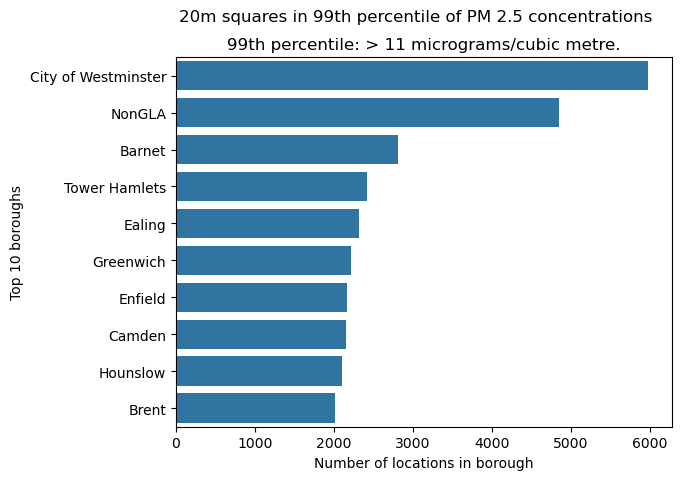

In [57]:
sns.barplot(data=gdf["Borough"].value_counts()[:10], orient="h")
plt.suptitle("20m squares in 99th percentile of PM 2.5 concentrations")
plt.title("One point = 20m x 20m square.")
plt.title("99th percentile: > 11 micrograms/cubic metre.")
plt.xlabel("Number of locations in borough")
plt.ylabel("Top 10 boroughs")
plt.show()

## Spatial join the (99th percentile) PM 2.5 concentrations data to the LAEI 2019 (1 km x 1 km) grid squares

This maps each 20 metre grid square to a London borough.

In [13]:
gdf = gpd.GeoDataFrame(percentile_99, 
                        geometry=gpd.points_from_xy(percentile_99["Easting"], percentile_99["Northing"]),
                        crs="EPSG:27700")

grid_contains_points = grid.sjoin(gdf, how="inner", predicate="contains")

## Calculate the median of the 99th percentile PM 2.5 concentrations in each LAEI 2019 grid square

In [83]:
cols = ["1km2_ID", "geometry", "Borough", "conc"]

median_conc_per_grid_square = grid_contains_points.groupby(["1km2_ID", "geometry", "Borough"])["conc"].median().reset_index()
median_conc_per_grid_square = median_conc_per_grid_square.rename(columns={"conc": "Median_PM2.5_concentration"})
# Reproject the British National Grid (BNG) eastings and northings to the WGS 1984 ellipsoid (latitudes and longitudes)
# This enables the data to be plotted on Google Maps
median_conc_per_grid_square = gpd.GeoDataFrame(median_conc_per_grid_square).to_crs("EPSG:4326")

## Plot a choropleth map of (99th percentile) median PM 2.5 emissions in the City of Westminster

This is the London Borough with the greatest number of 20 metre grid squares in the 99th percentile of PM 2.5 concentrations.

In [ ]:
westminster_medians = median_conc_per_grid_square[median_conc_per_grid_square["Borough"].str.contains("Westminster")]

In [88]:
london_centre = [51.51, -0.12]

m = folium.Map(location=london_centre, zoom_start=12)

folium.Choropleth(
    geo_data=westminster_medians,
    name="PM2.5_99thPercentile",
    data=westminster_medians,
    columns=["1km2_ID", "Median_PM2.5_concentration"],
    key_on="feature.properties.1km2_ID",
    fill_color="plasma",
    legend_name="PM 2.5 concentration (micrograms/cubic metre)",
 ).add_to(m)

folium.LayerControl().add_to(m)

m